In [630]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader , TensorDataset
from torchvision.utils import save_image, make_grid
from torch.optim import Adam
import torch.nn.init as init

import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

from scipy.stats import norm
from sklearn.neighbors import KernelDensity, LocalOutlierFactor
from sklearn.decomposition import PCA

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [631]:
def import_data(mode:list , num_policy:int , case:str, level:int=5):
    dataset = {key : [] for key in mode}
    for i in dataset.keys():   # run all mode
        for policy in range(num_policy): # each run have 3 policies
            if case == "slope":
                dataset[i].append(np.load(f"../data/{case}/{case}-{i}-ANGLE{str(level)}-policy_{policy}.npy" , allow_pickle=True).item())
            elif case == "mass":
                dataset[i].append(np.load(f"../data/{case}/{case}{level}-{i}-policy_{policy}.npy" , allow_pickle=True).item())
            else:
                dataset[i].append(np.load(f"../data/{case}/{case}-{i}-policy_{policy}.npy" , allow_pickle=True).item())
    for key, value in dataset.items():
        dataset[key] = np.array(value)
    return dataset

In [650]:
NUM_POLICY = 5
# Hebb vs CPG
# mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC" , "CPG_RBF"]
# Hebb only
# mode=["full","vel_act", "pos_act", "pos_vel_act", "act_FC", "act_IMU_FC", "pos_act_IMU", "pos_act_FC", "vel_act_IMU", "vel_act_FC"]
# Key sensor
# mode=["full", "pos_act",  "pos_vel_act",  "pos_act_FC","pos_act_IMU", "CPG_RBF" , "INT-full" , "INT-pos_act" , "INT-pos_vel_act" , "INT-pos_act_FC" , "INT-pos_act_IMU"]
# mode=["full", "pos_act_FC", "CPG_RBF" , "INT-full" , "INT-pos_act_FC" , "ff-full" , "ff-pos_act_FC"]
# mode=["full", "pos_act_FC", "CPG_RBF2" ]

mode=["pos_act_FC", "ff-full" , "CPG_RBF2", "INT5-pos_act_FC"]

slope_10    =   import_data(mode , NUM_POLICY , case="slope",level=-10)
slope10     =   import_data(mode , NUM_POLICY , case="slope",level=10)

# slope5      =   import_data(mode , NUM_POLICY , case="slope",level=5)
# slope15     =   import_data(mode , NUM_POLICY , case="slope",level=15)
# slope_5     =   import_data(mode , NUM_POLICY , case="slope",level=-5)
# slope_15    =   import_data(mode , NUM_POLICY , case="slope",level=-15)

mass1000    =   import_data(mode , NUM_POLICY , case="mass" , level=1000)
# mass250     =   import_data(mode , NUM_POLICY , case="mass" , level=250)
# mass500     =   import_data(mode , NUM_POLICY , case="mass" , level=500)
# mass2000    =   import_data(mode , NUM_POLICY , case="mass" , level=2000)
# mass5000    =   import_data(mode , NUM_POLICY , case="mass" , level=5000)
# mass10000   =   import_data(mode , NUM_POLICY , case="mass" , level=10000)

# fix_f       =   import_data(mode , NUM_POLICY , case="fix_f")
# fix_h       =   import_data(mode , NUM_POLICY , case="fix_h")
# fix_rf      =   import_data(mode , NUM_POLICY , case="fix_rf")
# morph2       =   import_data(mode , NUM_POLICY , case="morph2")
# morph3       =   import_data(mode , NUM_POLICY , case="morph3")
# narrow      =   import_data(mode , NUM_POLICY , case="narrow")
# stair      =   import_data(mode , NUM_POLICY , case="stair")
# obstacle      =   import_data(mode , NUM_POLICY , case="obstacle")
# ceilling    =   import_data(mode , NUM_POLICY , case="ceilling")
# uniform     =   import_data(mode , NUM_POLICY , case="uniform")

flat        =   import_data(mode , NUM_POLICY , case="flat")
rough       =   import_data(mode , NUM_POLICY , case="rough")
# box         =   import_data(mode , NUM_POLICY , case="box")
morph       =   import_data(mode , NUM_POLICY , case="morph")
# rough2      =   import_data(mode , NUM_POLICY , case="rough2")
# fix_body    =   import_data(mode , NUM_POLICY , case="fix_body")
loss100     =   import_data(mode , NUM_POLICY , case="loss100")

slope_list      = [slope10 ,slope_10 ] # The 15 is slip so the result is shown in not significant way. [slope5 , slope10 , slope15 , slope_5 , slope_10 ,  slope_15]
slope_list_str  = ["slope10" , "slope_10"]


mass_list       = [mass1000] # [mass250 , mass500 , mass1000 , mass2000 , mass5000 , mass10000
mass_list_str   = ["mass1000"]
# [case:str][number_file:int][data/brain:str]

## Preprocess Data

In [633]:
def preprocess(selected_dataset , num_pol):
    performance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    max_distance = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}
    avg_vel = {f"policy{n_policy}": {case: [] for case in selected_dataset.keys()} for n_policy in range(num_pol)}

    for policy in range(num_pol):
        for case in selected_dataset.keys():
            reward = np.sum(selected_dataset[case][policy]["data"]['reward'], axis=0)
            performance[f"policy{policy}"][case] = reward

            max_pos_x = np.max(selected_dataset[case][policy]["data"]['pos_x'], axis=0)
            max_distance[f"policy{policy}"][case] = max_pos_x

            vel_x = selected_dataset[case][policy]["data"]['vel_b'][:,:,0]
            avg_vel[f"policy{policy}"][case] = np.mean(vel_x ,axis=0)
    return performance , max_distance , avg_vel

def preprocess_combined(selected_dataset, num_pol):
    """
    Combine values from ALL policies into one 'policy_all' per case.

    Returns:
        performance_all, max_distance_all, avg_vel_all
        # Each is a dict like:
        # {
        #   'policy_all': {
        #       <case_a>: np.ndarray(... concatenated from all policies ...),
        #       <case_b>: np.ndarray(...),
        #       ...
        #   }
        # }
    """
    cases = list(selected_dataset.keys())

    # Buckets (lists) to collect per-policy arrays before concatenating
    perf_bucket = {case: [] for case in cases}
    dist_bucket = {case: [] for case in cases}
    vel_bucket  = {case: [] for case in cases}

    for policy in range(num_pol):
        for case in cases:
            data = selected_dataset[case][policy]["data"]

            # 1) reward sum over time -> shape (..., ?) then flatten along new axis 0
            reward = np.sum(data["reward"], axis=0)
            perf_bucket[case].append(np.ravel(reward))

            # 2) max pos_x over time
            max_pos_x = np.max(data["pos_x"], axis=0)
            dist_bucket[case].append(np.ravel(max_pos_x))

            # 3) avg vel_x over time (take x component from vel_b[..., 0])
            vel_x = data["vel_b"][:, :, 0]
            avg_vel_x = np.mean(vel_x, axis=0)
            vel_bucket[case].append(np.ravel(avg_vel_x))

    # Concatenate across all policies so each case has one long vector
    performance_all = {"policy": {case: np.concatenate(perf_bucket[case], axis=0) if len(perf_bucket[case]) else np.array([]) for case in cases}}
    max_distance_all = {"policy": {case: np.concatenate(dist_bucket[case], axis=0) if len(dist_bucket[case]) else np.array([]) for case in cases}}
    avg_vel_all = {"policy": {case: np.concatenate(vel_bucket[case], axis=0) if len(vel_bucket[case]) else np.array([]) for case in cases}}

    return performance_all, max_distance_all, avg_vel_all

In [634]:
from matplotlib.colors import to_rgb

def _pastel_colors(n):
    """Generate n pastel-ish colors by blending tab10 with white."""
    base = ["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd",
            "#8c564b","#e377c2","#7f7f7f","#bcbd22","#17becf"]
    blend = []
    for i in range(n):
        r, g, b = to_rgb(base[i % len(base)])
        r = 0.7*1.0 + 0.3*r
        g = 0.7*1.0 + 0.3*g
        b = 0.7*1.0 + 0.3*b
        blend.append((r, g, b))
    return blend

def plot_case_boxplot(
    metric_all: dict,
    policy_key: str = "policy",
    title: str = "Distribution by Case",
    ylabel: str = "",
    ylim: list=[0,5],
    rotate_xticks: int = 20,
    notch: bool = False,
    showfliers: bool = True,
    savepath: str | None = None,
    show: bool = True,
    # --- pastel boxes ---
    pastel: bool = True,
    pastel_alpha: float = 0.9,
    # --- jittered points ---
    show_points: bool = True,
    jitter: float = 0.08,      # stddev of x-jitter (in axis units)
    point_size: float = 8,
    point_alpha: float = 0.6,
    rng_seed: int | None = None,
):
    """
    Plot one pastel-filled box per case and overlay jittered points.

    Expects: metric_all = { "policy": { caseA: np.ndarray, caseB: np.ndarray, ... } }
    Returns: (fig, ax)
    """
    if policy_key not in metric_all:
        raise KeyError(f"Expected key '{policy_key}' in metric_all. Got keys: {list(metric_all.keys())}")

    case_map = metric_all[policy_key]

    cases, data = [], []
    for case, arr in case_map.items():
        arr = np.asarray(arr)
        if arr.size == 0:
            continue
        cases.append(case)
        data.append(arr)

    if len(data) == 0:
        raise ValueError("No non-empty case arrays found to plot.")

    rng = np.random.default_rng(rng_seed)

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(
        data,
        tick_labels=cases,
        notch=notch,
        showfliers=showfliers,
        vert=True,
        patch_artist=True,  # needed to fill boxes
        medianprops={"color": "black", "linewidth": 1.4},
        whiskerprops={"color": "black", "linewidth": 1.0},
        capprops={"color": "black", "linewidth": 1.0},
    )

    # --- Pastel fill ---
    if pastel:
        colors = _pastel_colors(len(data))
        for box, c in zip(bp["boxes"], colors):
            box.set(facecolor=c, edgecolor="black", alpha=pastel_alpha, linewidth=1.0)

    # --- Jittered points overlay ---
    if show_points:
        # clip jitter inside the box’s general x-span
        clip_half_width = 0.35
        for i, arr in enumerate(data, start=1):
            xj = i + rng.normal(0.0, jitter, size=arr.size)
            xj = np.clip(xj, i - clip_half_width, i + clip_half_width)
            ax.scatter(
                xj, arr,
                s=point_size,
                alpha=point_alpha,
                edgecolors="none",
                zorder=3
            )

    # Titles & labels
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if ylim != 0:
        ax.set_ylim([ ylim[0] , ylim[1]])
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    if rotate_xticks:
        for tick in ax.get_xticklabels():
            tick.set_rotation(rotate_xticks)
            tick.set_ha("right")

    # annotate mean (3 decimals)
    y_min = ax.get_ylim()[0]
    for i, arr in enumerate(data, start=1):
        ax.text(i, y_min, f"μ={arr.mean():.3f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=150, bbox_inches="tight")
    if show:
        plt.show()

    return fig, ax

In [635]:
def plot_performance_all_in_one(performance: dict, title: str = "Performance (All Policies)" , ylim=350):
    policies = list(performance.keys())
    if not policies:
        raise ValueError("performance must contain at least one policy")

    # Stable case order
    first_cases = list(performance[policies[0]].keys())
    all_cases = set(first_cases)
    for p in policies[1:]:
        all_cases |= set(performance[p].keys())
    case_order = first_cases + [c for c in all_cases if c not in first_cases]

    num_cases = len(case_order)
    num_policies = len(policies)

    pastel_colors = sns.color_palette("pastel", n_colors=num_cases)
    case_colors = {case: pastel_colors[i] for i, case in enumerate(case_order)}

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    group_width = 0.8
    box_width = group_width / max(2, num_policies)
    offsets = np.linspace(-group_width/2 + box_width/2, group_width/2 - box_width/2, num_policies)

    for i, policy in enumerate(policies):
        # Ensure each is a list/array (empty allowed)
        data = [np.asarray(performance[policy].get(case, [])) for case in case_order]
        positions = [j + offsets[i] for j in range(1, num_cases + 1)]

        box = ax.boxplot(
            data,
            positions=positions,
            widths=box_width * 0.9,
            vert=True,
            patch_artist=True,
            zorder=1
        )

        # Color by case
        for j, patch in enumerate(box['boxes']):
            patch.set_facecolor(case_colors[case_order[j]])

        # Scatter with safe empties
        for j, vals in enumerate(data):
            if vals.size == 0:
                continue
            x_center = positions[j]
            x_vals = x_center + np.random.normal(0, box_width * 0.12, size=vals.size)
            ax.scatter(x_vals, vals, alpha=0.8, s=5, zorder=2)

    ax.set_xticks(range(1, num_cases + 1))
    ax.set_xticklabels(case_order, fontsize=8, rotation=45)
    ax.set_ylim(0, ylim)
    ax.set_title(title)

    handles = [plt.Line2D([0],[0], marker='s', linestyle='',
                          markerfacecolor=case_colors[c], markeredgecolor='k', markersize=8, label=c)
               for c in case_order]
    ax.legend(handles=handles, title="Case", loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- Return averages (NumPy-safe empties) ---
    policy_case_mean = {}
    for p in policies:
        case_means = {}
        for c in case_order:
            vals = np.asarray(performance[p].get(c, []))
            case_means[c] = float(np.mean(vals)) if vals.size > 0 else float('nan')
        policy_case_mean[p] = case_means

    overall_case_mean = {}
    for c in case_order:
        all_vals = []
        for p in policies:
            v = np.asarray(performance[p].get(c, []))
            if v.size > 0:
                all_vals.append(v)
        if len(all_vals) == 0:
            overall_case_mean[c] = float('nan')
        else:
            overall_case_mean[c] = float(np.mean(np.concatenate(all_vals)))

    return {
        "overall_case_mean": overall_case_mean,
        "policy_case_mean": policy_case_mean
    }

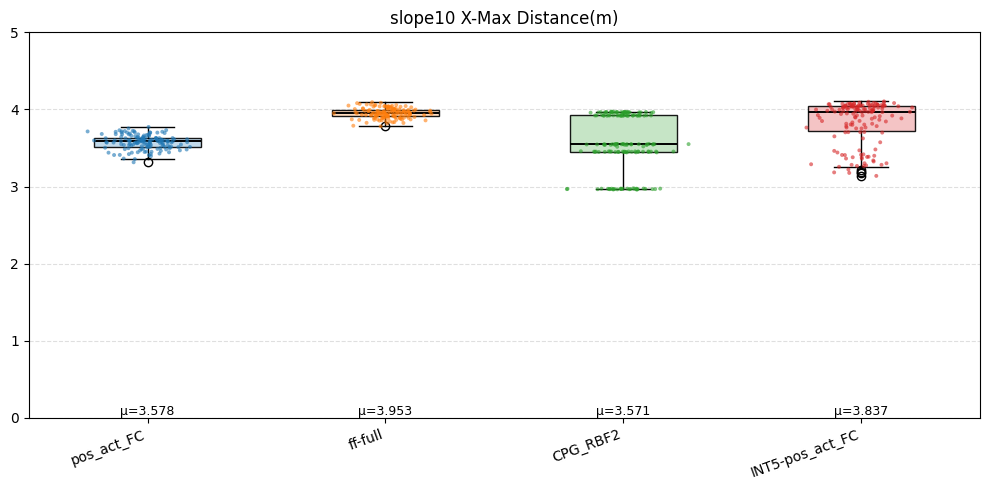

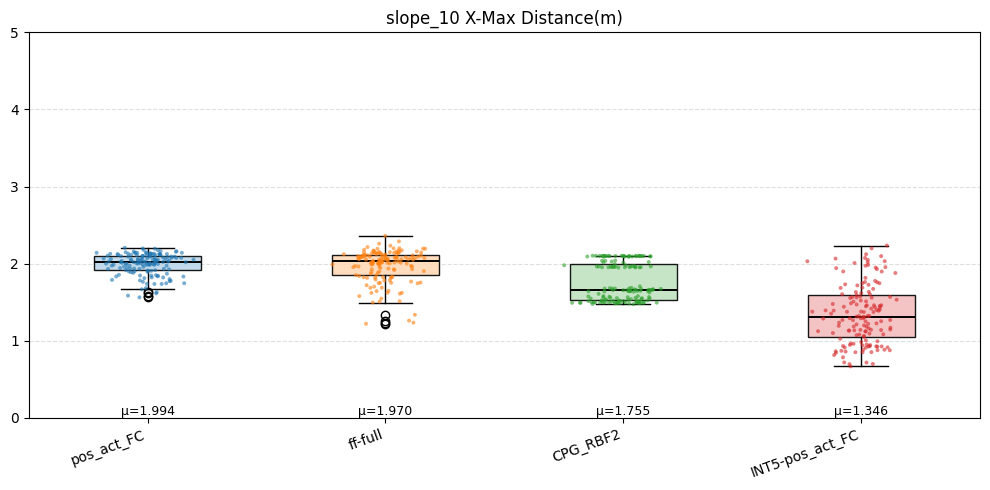

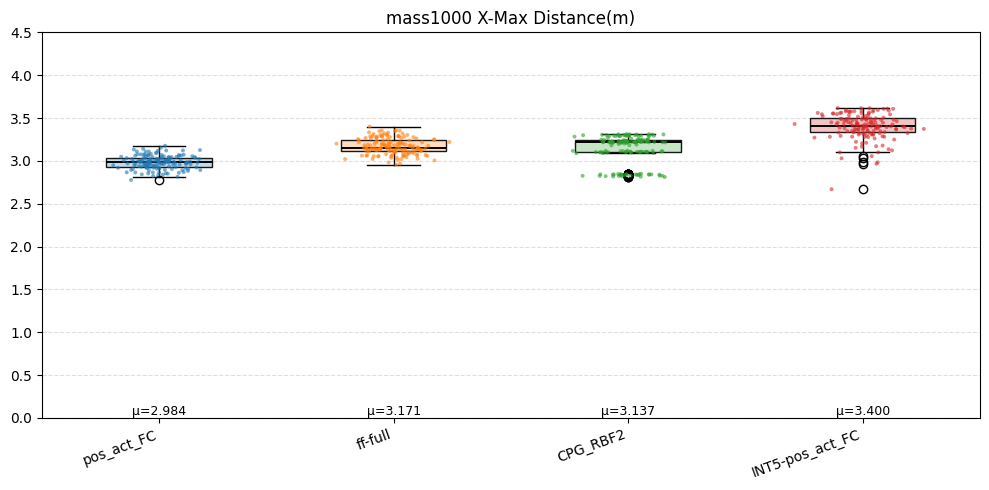

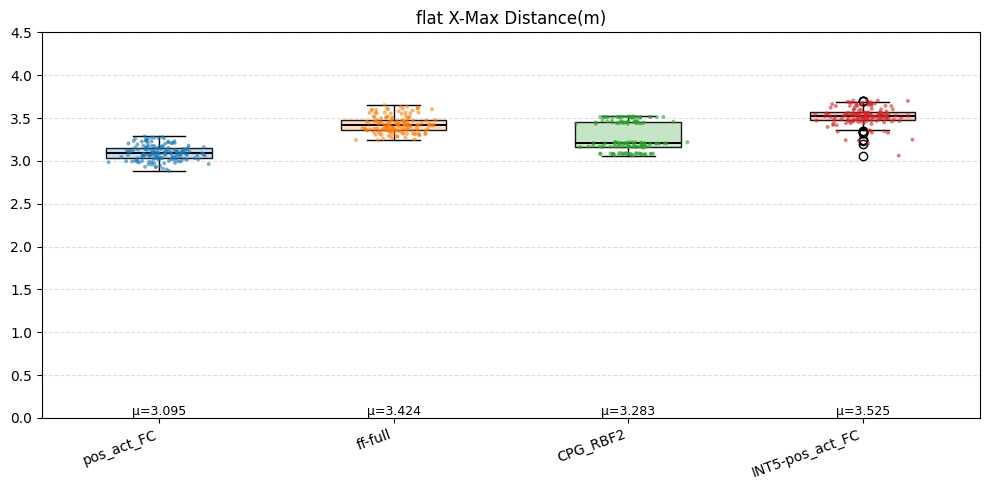

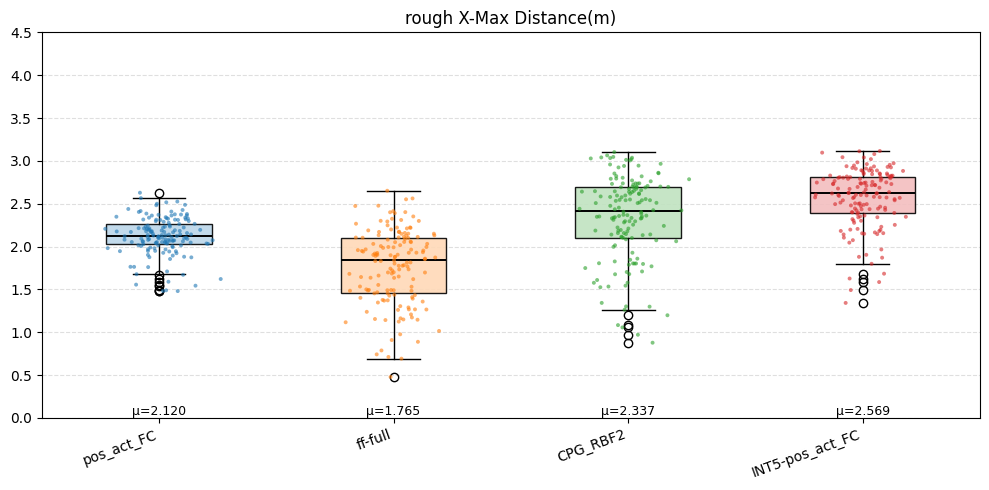

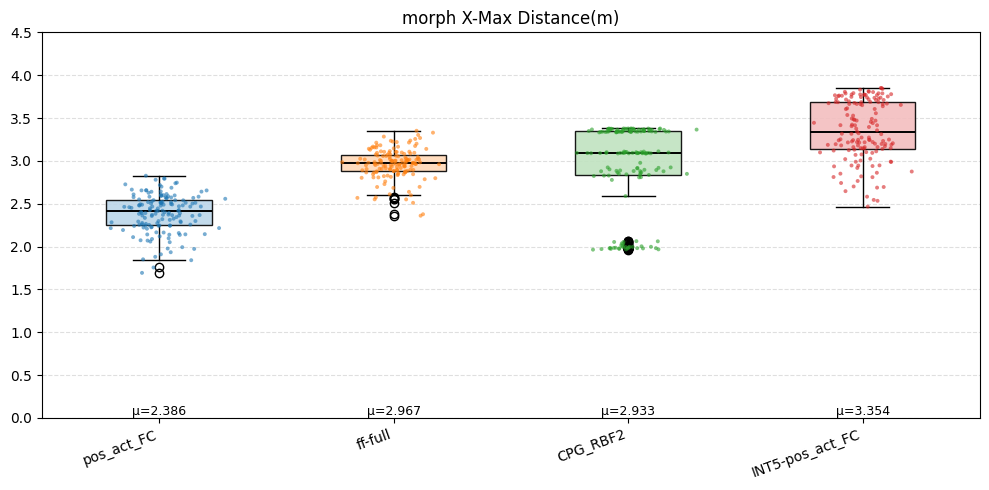

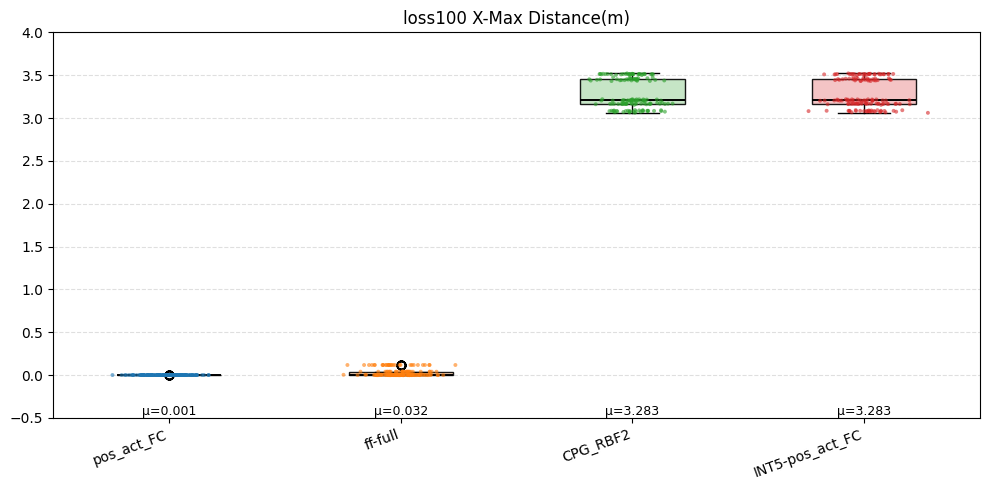

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'loss100 X-Max Distance(m)'}>)

In [652]:
num_pol = 5
max_distance = {}
reward = {}
avg_vel = {}

# Get performance criteria
# Slope data
for idx , slope_data in enumerate(slope_list):
    reward[slope_list_str[idx]] , max_distance[slope_list_str[idx]] , avg_vel[slope_list_str[idx]]= preprocess_combined(selected_dataset=slope_data , num_pol=num_pol)

# Mass data
for idx , mass_data in enumerate(mass_list):
    reward[mass_list_str[idx]] , max_distance[mass_list_str[idx]] , avg_vel[mass_list_str[idx]]= preprocess_combined(selected_dataset=mass_data , num_pol=num_pol)

reward["flat"] , max_distance["flat"] , avg_vel["flat"] = preprocess_combined(selected_dataset=flat , num_pol=num_pol)
reward["rough"] , max_distance["rough"] , avg_vel["rough"] = preprocess_combined(selected_dataset=rough , num_pol=num_pol)
# reward["rough2"] , max_distance["rough2"] , avg_vel["rough2"] = preprocess_combined(selected_dataset=rough2 , num_pol=num_pol)
reward["morph"] , max_distance["morph"] , avg_vel["morph"] = preprocess_combined(selected_dataset=morph , num_pol=num_pol)
# reward["box"] , max_distance["box"] , avg_vel["box"] = preprocess_combined(selected_dataset=box , num_pol=num_pol)
# reward["fix_body"] , max_distance["fix_body"] , avg_vel["fix_body"] = preprocess_combined(selected_dataset=fix_body , num_pol=num_pol)
reward["loss100"] , max_distance["loss100"] , avg_vel["loss100"] = preprocess_combined(selected_dataset=loss100 , num_pol=num_pol)


# reward["fix_f"] , max_distance["fix_f"] , avg_vel["fix_f"] = preprocess_combined(selected_dataset=fix_f , num_pol=num_pol)
# reward["fix_h"] , max_distance["fix_h"] , avg_vel["fix_h"] = preprocess_combined(selected_dataset=fix_h , num_pol=num_pol)
# reward["fix_rf"] , max_distance["fix_rf"] , avg_vel["fix_rf"] = preprocess_combined(selected_dataset=fix_rf , num_pol=num_pol)
# reward["morph2"] , max_distance["morph2"] , avg_vel["morph2"] = preprocess_combined(selected_dataset=morph2 , num_pol=num_pol)
# reward["morph3"] , max_distance["morph3"] , avg_vel["morph3"] = preprocess_combined(selected_dataset=morph3 , num_pol=num_pol)
# reward["narrow"] , max_distance["narrow"] , avg_vel["narrow"] = preprocess_combined(selected_dataset=narrow , num_pol=num_pol)
# reward["uniform"] , max_distance["uniform"] , avg_vel["uniform"] = preprocess_combined(selected_dataset=uniform , num_pol=num_pol)
# reward["stair"] , max_distance["stair"] , avg_vel["stair"] = preprocess_combined(selected_dataset=stair , num_pol=num_pol)
# reward["obstacle"] , max_distance["obstacle"] , avg_vel["obstacle"] = preprocess_combined(selected_dataset=obstacle , num_pol=num_pol)
# reward["ceilling"] , max_distance["ceilling"] , avg_vel["ceilling"] = preprocess_combined(selected_dataset=ceilling , num_pol=num_pol)

###############################################################################################################################

# Plotting :)
for slope_str in slope_list_str:
    plot_case_boxplot(metric_all=max_distance[slope_str], policy_key="policy" , title=f"{slope_str} X-Max Distance(m)", ylim=[0,5.0])
for mass_str in mass_list_str:
    plot_case_boxplot(metric_all=max_distance[mass_str], policy_key="policy" , title=f"{mass_str} X-Max Distance(m)", ylim=[0,4.5])
# plot_case_boxplot(metric_all=max_distance['slope10'], policy_key="policy" , title=f"{"slope_10"} X-Max Distance(m)", ylim=[0,5.0])
# plot_case_boxplot(metric_all=max_distance["slope_10"], policy_key="policy" , title=f"{"slope_10"} X-Max Distance(m)", ylim=[0,4.5])

plot_case_boxplot(metric_all=max_distance["flat"], policy_key="policy" , title=f"flat X-Max Distance(m)", ylim=[0,4.5])
plot_case_boxplot(metric_all=max_distance["rough"], policy_key="policy" , title=f"rough X-Max Distance(m)", ylim=[0,4.5])
# plot_case_boxplot(metric_all=max_distance["rough2"], policy_key="policy" , title=f"rough2 X-Max Distance(m)", ylim=[0,4.5])
plot_case_boxplot(metric_all=max_distance["morph"], policy_key="policy" , title=f"morph X-Max Distance(m)", ylim=[0,4.5])
# plot_case_boxplot(metric_all=max_distance["box"], policy_key="policy" , title=f"box X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["fix_body"], policy_key="policy" , title=f"fix_body X-Max Distance(m)", ylim=[-2,4])
plot_case_boxplot(metric_all=max_distance["loss100"], policy_key="policy" , title=f"loss100 X-Max Distance(m)", ylim=[-0.5,4])

# plot_case_boxplot(metric_all=max_distance["fix_f"], policy_key="policy" , title=f"fix_f X-Max Distance(m)", ylim=[-2,4])
# plot_case_boxplot(metric_all=max_distance["fix_rf"], policy_key="policy" , title=f"fix_rf X-Max Distance(m)", ylim=[-2,4])
# plot_case_boxplot(metric_all=max_distance["fix_h"], policy_key="policy" , title=f"fix_h X-Max Distance(m)", ylim=[-2,4])

# plot_case_boxplot(metric_all=max_distance["morph2"], policy_key="policy" , title=f"morph2 X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["morph3"], policy_key="policy" , title=f"morph3 X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["stair"], policy_key="policy" , title=f"stair X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["obstacle"], policy_key="policy" , title=f"obstacle X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["narrow"], policy_key="policy" , title=f"narrow X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["ceilling"], policy_key="policy" , title=f"ceilling X-Max Distance(m)", ylim=[0,4])
# plot_case_boxplot(metric_all=max_distance["uniform"], policy_key="policy" , title=f"uniform X-Max Distance(m)", ylim=[-2,4])


# temp_reward,temp_max_distance,temp_avg_reward = {},{},{}
# temp_reward["flat"] , temp_max_distance["flat"] , temp_avg_reward["flat"] = preprocess(selected_dataset=obstacle, num_pol=num_pol)
# plot_performance_all_in_one(temp_max_distance["flat"] ,ylim=5)



## Scoring

In [637]:
def scoring(
        performance:dict , 
        policy_key:str="policy",
        max_score:int=10
        ):
    buff = {}
    max = -99.0
    for case in performance[policy_key].keys():
        performance[policy_key]
        buff[case] = performance[policy_key][case].mean()
        if buff[case] > max:
            max = buff[case]

    for key in buff.keys():
        buff[key] = (buff[key] * max_score)/max
    return buff


In [638]:
def plot_score(d: dict, title="Scores by Mode", ylabel="Score",
                       sort_by="key", rotate_xticks=30, annotate=True):
    """
    d: dict[str, number]  (e.g., {'full': np.float32(10.0), ...})
    sort_by: "key" | "value" | None
    """
    # Make sure we have Python floats
    items = [(k, float(v)) for k, v in d.items()]

    if sort_by == "key":
        items.sort(key=lambda x: x[0])
    elif sort_by == "value":
        items.sort(key=lambda x: x[1], reverse=True)

    labels = [k for k, _ in items]
    values = [v for _, v in items]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(labels, values)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if rotate_xticks:
        for t in ax.get_xticklabels():
            t.set_rotation(rotate_xticks)
            t.set_ha("right")

    if annotate:
        for bar, v in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout()
    plt.show()
    return fig, ax

In [639]:
def aggregate_sensor_scores(scores: dict, agg: str = "sum"):
    """
    Aggregate sensor_case scores across test cases.

    Args:
        scores: dict like {test_case: {sensor_case: number, ...}, ...}
        agg: "sum" or "mean"

    Returns:
        totals: dict {sensor_case: aggregated_score}
        best_sensor: (sensor_case, aggregated_score)
    """
    # union of all sensor_case keys
    all_sensors = set()
    for tc in scores.values():
        all_sensors |= set(tc.keys())

    totals = {sensor: 0.0 for sensor in all_sensors}
    counts = {sensor: 0 for sensor in all_sensors}

    for tc, sensor_map in scores.items():
        for sensor in all_sensors:
            if sensor in sensor_map:
                val = float(sensor_map[sensor])  # handles np.float32
                totals[sensor] += val
                counts[sensor] += 1

    if agg == "mean":
        for s in totals:
            totals[s] = totals[s] / counts[s] if counts[s] > 0 else float("nan")
    elif agg != "sum":
        raise ValueError("agg must be 'sum' or 'mean'")

    best_sensor = max(totals.items(), key=lambda kv: kv[1])
    return totals, best_sensor

In [640]:
scores = {}
for key in max_distance.keys():
    scores[key] = scoring(performance=max_distance[key],policy_key="policy",max_score=10)

# Mass score regularize
if scores["mass1000"] is not None:
    scores["mass"] = {m : 0 for m in mode}  # init the new dict
    for idx,mass in enumerate(mass_list_str):
        for sensor in scores[mass].keys():
            scores["mass"][sensor] += scores[mass][sensor] # sum all sensor case
        del scores[mass]
        
# slope score regularize
if scores["slope10"] is not None:
    scores["slope"] = {m : 0 for m in mode}  # init the new dict
    for idx,slope in enumerate(slope_list_str):
        for sensor in scores[slope].keys():
            scores["slope"][sensor] += scores[slope][sensor] # sum all sensor case
        del scores[slope]
    # average scores
    for i,sens in enumerate(mode):
        scores["mass"][sens] = scores["mass"][sens]/(len(mass_list_str))
        scores["slope"][sens] = scores["slope"][sens]/(len(slope_list_str))

totals, best = aggregate_sensor_scores(scores, agg="mean")   # or agg="mean"

print("Totals by sensor_case:")
for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True):
    print(f"{k:>12}: {v:.3f}")

Totals by sensor_case:
    CPG_RBF2: 9.870
        full: 9.383
  pos_act_FC: 9.221


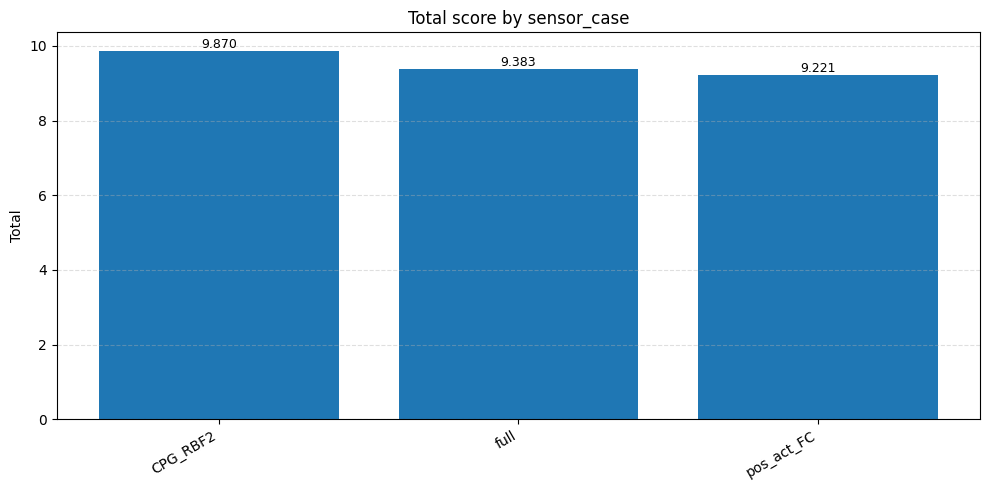

In [641]:
fig, ax = plot_score(totals, title="Total score by sensor_case", ylabel="Total", sort_by="value")

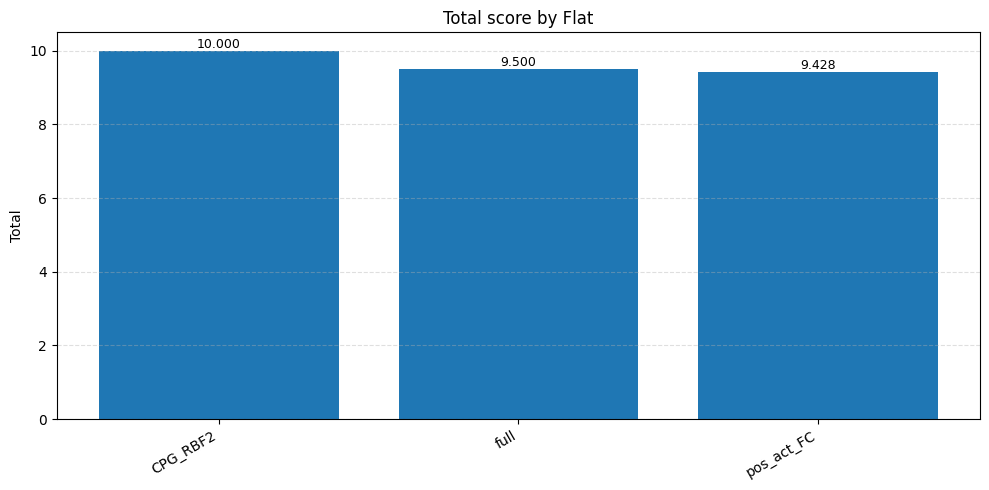

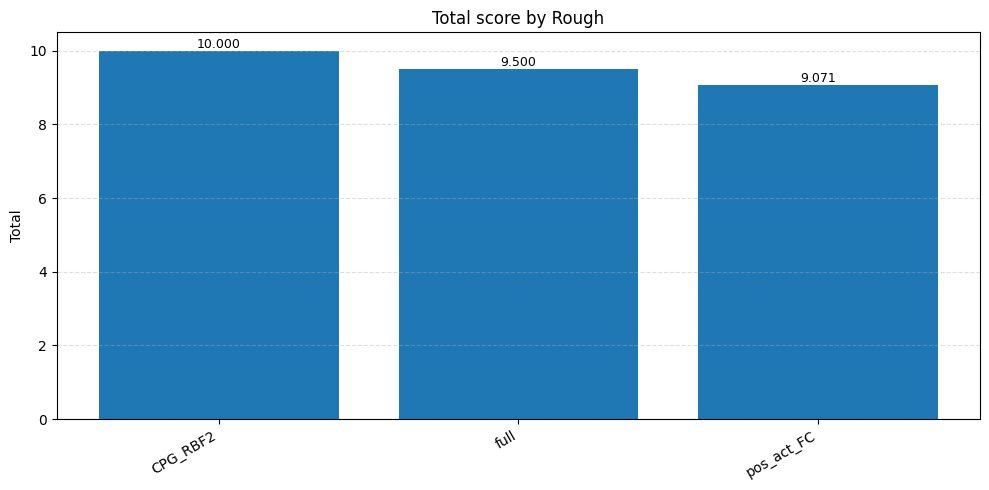

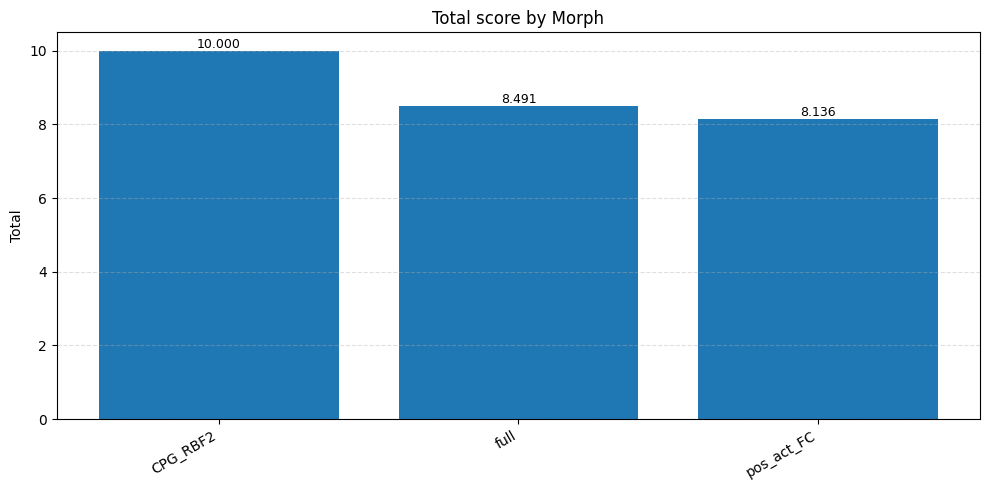

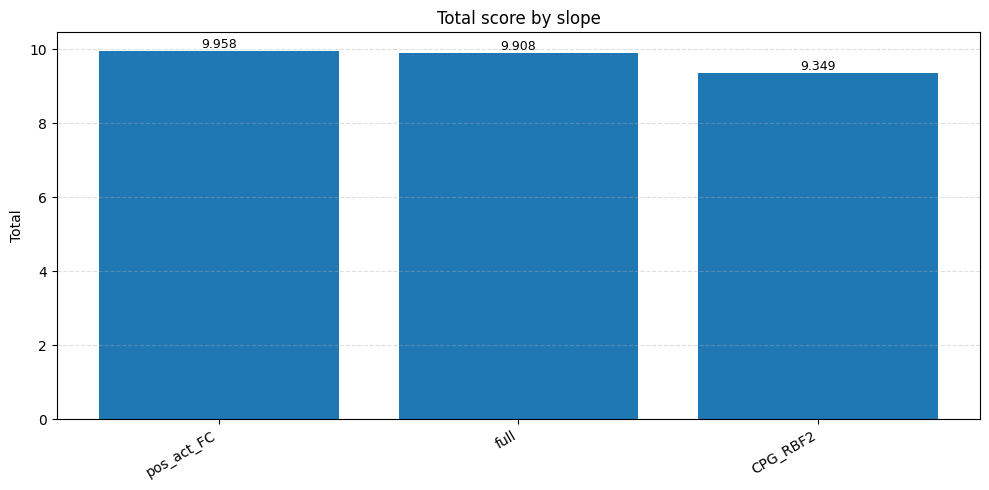

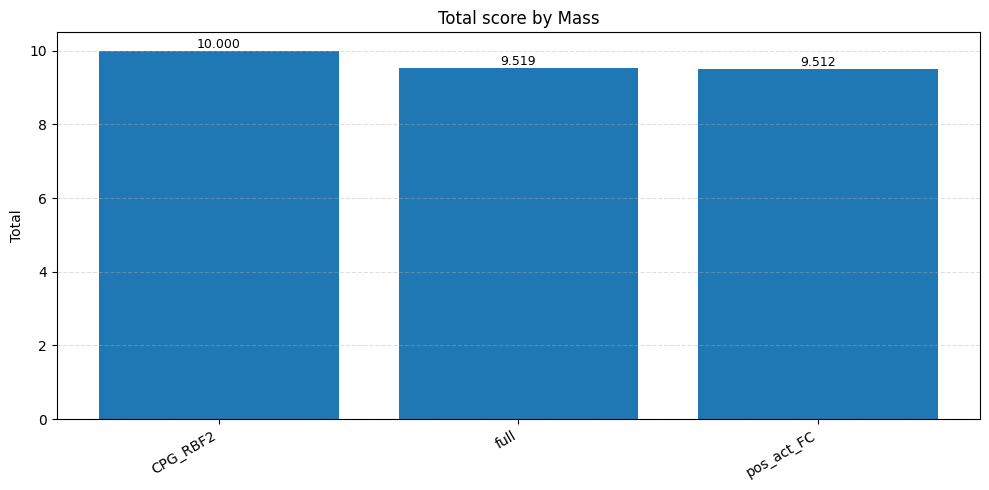

KeyError: 'fix_body'

In [642]:
fig, ax = plot_score(scores["flat"], title="Total score by Flat", ylabel="Total", sort_by="value")
# fig, ax = plot_score(scores["uniform"], title="Total score by Flat", ylabel="uniform", sort_by="value")

fig, ax = plot_score(scores["rough"], title="Total score by Rough", ylabel="Total", sort_by="value")
fig, ax = plot_score(scores["morph"], title="Total score by Morph", ylabel="Total", sort_by="value")
fig, ax = plot_score(scores["slope"], title="Total score by slope", ylabel="Total", sort_by="value")
fig, ax = plot_score(scores["mass"], title="Total score by Mass", ylabel="Total", sort_by="value")
fig, ax = plot_score(scores["fix_body"], title="Total score by fix_body", ylabel="Total", sort_by="value")

# fig, ax = plot_score(scores["slope_10"], title="Total score by slope -10 deg", ylabel="Total", sort_by="value")